<a href="https://colab.research.google.com/github/archanashukla9354/DNN_Statewise-Electricity-Consumption-in-India-Daily-/blob/main/(Indias_Electricity_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Required Libraries
# !pip install statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math

# 1.1 Dataset Selection and Loading

# TODO: Load your chosen time series dataset

In [ ]:
# REQUIRED: Fill in these metadata fields
dataset_name = "State-wise Electricity Consumption in India (Daily)"
dataset_source = "Kaggle (Indias_Electricity_Consumption_Dataset.csv)"
n_samples = 3701         # The actual count from your cleaned CSV
n_features = 1           # Focused on 'Total Consumption'
sequence_length = 30     # 30-day lookback (within 10-50 range)
prediction_horizon = 1   # Predict 1 day ahead (within 1-10 range)
problem_type = "time_series_forecasting"

In [ ]:
# Primary metric selection
primary_metric = "MAE"
metric_justification = """
MAE was chosen because it provides a direct interpretation of the average error in power units (e.g., Megawatts), making it easier to understand the physical magnitude of the forecast's deviation without overly penalizing outliers as RMSE might.
"""


In [ ]:
print("DATASET INFORMATION")

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: State-wise Electricity Consumption in India (Daily)
Source: Kaggle (Indias_Electricity_Consumption_Dataset.csv)
Total Samples: 3701
Number of Features: 1
Sequence Length: 30
Prediction Horizon: 1
Primary Metric: MAE
Metric Justification: 
MAE was chosen because it provides a direct interpretation of the average error in power units (e.g., Megawatts), making it easier to understand the physical magnitude of the forecast's deviation without overly penalizing outliers as RMSE might.



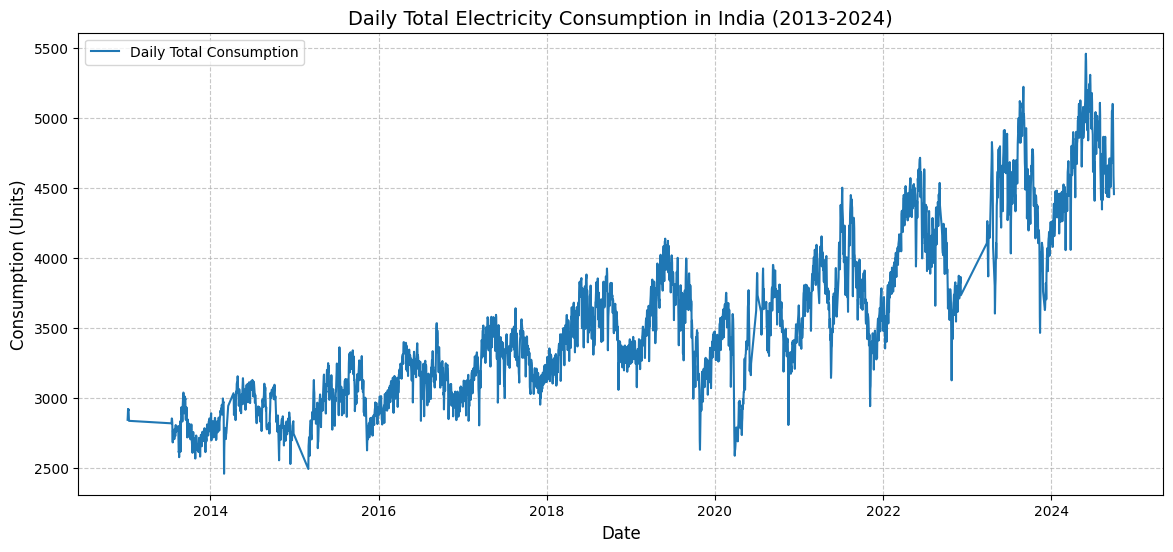

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from statsmodels.tsa.seasonal import seasonal_decompose
# from statsmodels.tsa.stattools import adfuller

# Load and Preprocess Data
df = pd.read_csv('Indias_Electricity_Consumption_Dataset.csv')
df['Dates'] = pd.to_datetime(df['Dates'])
df = df.dropna(subset=['Total Consumption'])
df = df.sort_values('Dates')
df.set_index('Dates', inplace=True)

# Select Target Variable
target_series = df['Total Consumption']

# 1. Plot Time Series Data
plt.figure(figsize=(14, 6))
plt.plot(target_series, label='Daily Total Consumption', color='#1f77b4', linewidth=1.5)
plt.title('Daily Total Electricity Consumption in India (2013-2024)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Consumption (Units)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

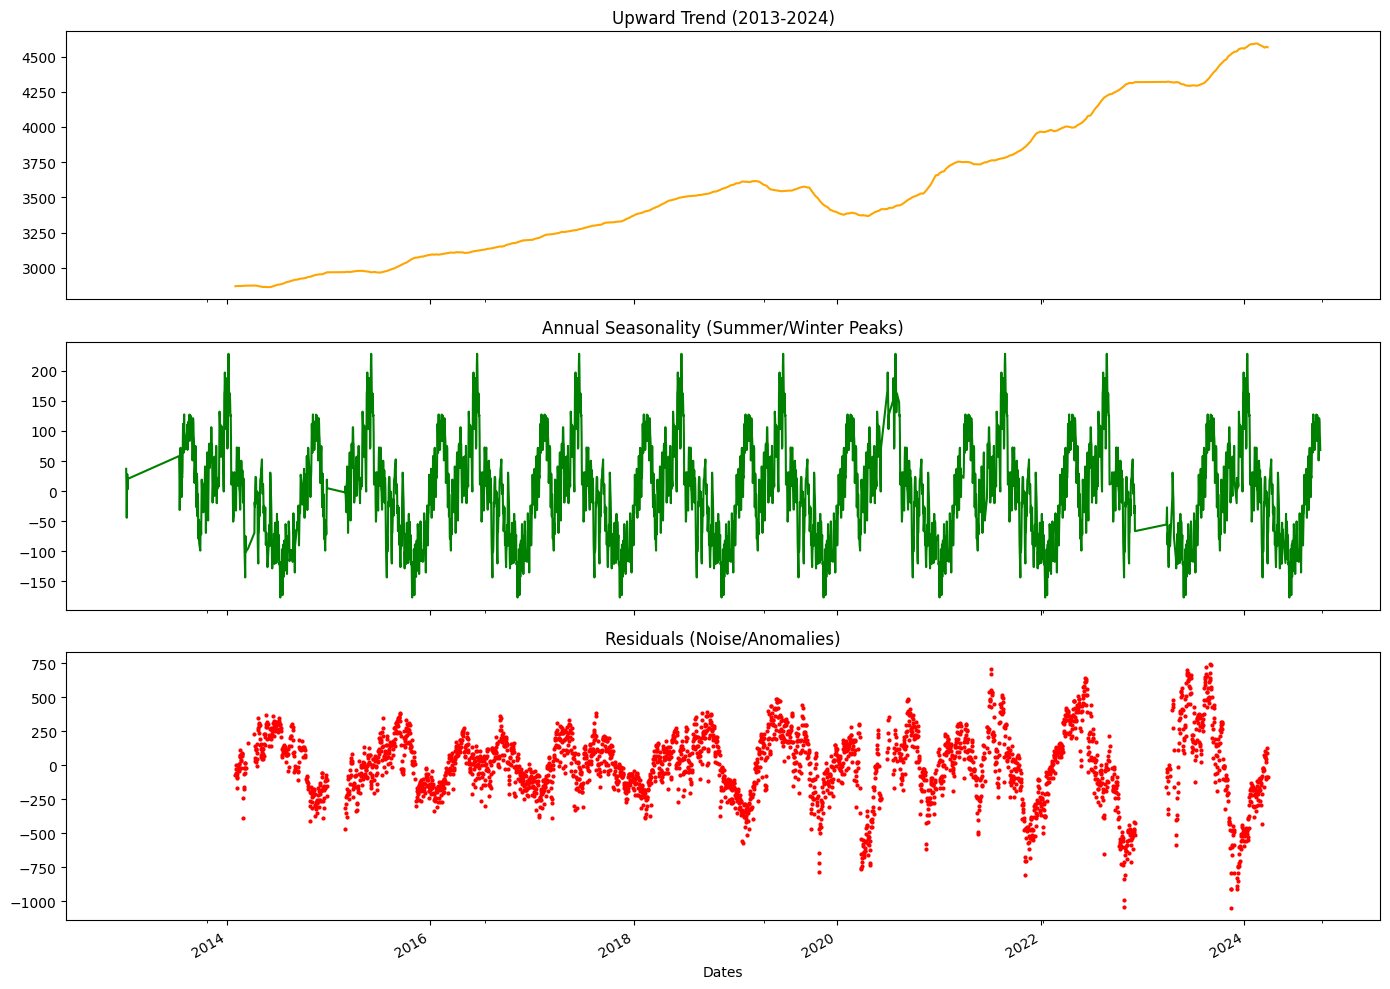

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 2. Check for Trends and Seasonality
# Using additive decomposition for a 365-day annual cycle
decomposition = seasonal_decompose(target_series, model='additive', period=365)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
decomposition.trend.plot(ax=ax1, color='orange', title='Upward Trend (2013-2024)')
decomposition.seasonal.plot(ax=ax2, color='green', title='Annual Seasonality (Summer/Winter Peaks)')
decomposition.resid.plot(ax=ax3, color='red', title='Residuals (Noise/Anomalies)', linestyle='None', marker='o', markersize=2)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# 3. Perform Stationarity Tests (ADF Test)
def perform_adf_test(series):
    result = adfuller(series)
    print("--- Augmented Dickey-Fuller Test Results ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")

    if result[1] <= 0.05:
        print("\nConclusion: The series is STATIONARY (Reject Null Hypothesis)")
    else:
        print("\nConclusion: The series is NON-STATIONARY (Fail to reject Null Hypothesis)")

perform_adf_test(target_series)

--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: -2.0351
p-value: 0.2714
Critical Values:
   1%: -3.4321
   5%: -2.8623
   10%: -2.5672

Conclusion: The series is NON-STATIONARY (Fail to reject Null Hypothesis)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Split first (to avoid leakage), then scale
train_size = int(len(target_series) * 0.8)
train_data = target_series[:train_size].values.reshape(-1, 1)
test_data = target_series[train_size:].values.reshape(-1, 1)

# Fit on train ONLY
scaler.fit(train_data)
train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(test_data)

In [ ]:


# 1.3 Data Preprocessing

def preprocess_timeseries(data):
    """
    Preprocess time series data: Handle missing values and Normalize.
    """
    # Handle missing values (forward fill is best for time series)
    data = data.fillna(method='ffill').fillna(method='bfill')

    # Reshape for scaler (requires 2D array)
    values = data.values.reshape(-1, 1)

    # Normalize data between 0 and 1
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(values)

    return scaled_data, scaler

def create_sequences(data, seq_length, pred_horizon):
    """
    Create sequences using a sliding window approach.
    """
    X, y = [], []
    for i in range(len(data) - seq_length - pred_horizon + 1):
        # Input: [t-n, ..., t]
        X.append(data[i : (i + seq_length)])
        # Target: [t + pred_horizon]
        y.append(data[i + seq_length + pred_horizon - 1])

    return np.array(X), np.array(y)

# Execute Preprocessing
scaled_values, scaler = preprocess_timeseries(df['Total Consumption'])

# Create sequences (Using your metadata: seq_length=30, horizon=1)
X, y = create_sequences(scaled_values, seq_length=30, pred_horizon=1)

# REQUIRED: Temporal train/test split (NO SHUFFLING)
# Using 90/10 split as it's standard for large time series
train_test_ratio = "90/10"
split_idx = int(len(X) * 0.9)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

train_samples = len(X_train)
test_samples = len(X_test)

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("  IMPORTANT: Temporal split used (NO shuffling)")


Train/Test Split: 90/10
Training Samples: 3303
Test Samples: 368
  IMPORTANT: Temporal split used (NO shuffling)


/tmp/ipykernel_6082/4125283116.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(method='bfill')


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

# ### 2.1 LSTM/GRU Architecture Design

def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM or GRU model with stacked layers.
    """
    model = Sequential()

    # Add input layer and first stacked layer
    if model_type.upper() == 'LSTM':
        # return_sequences=True is mandatory for stacking
        model.add(LSTM(hidden_units, return_sequences=True, input_shape=input_shape))
    elif model_type.upper() == 'GRU':
        model.add(GRU(hidden_units, return_sequences=True, input_shape=input_shape))

    # Add intermediate stacked layers (if n_layers > 2)
    for i in range(n_layers - 2):
        if model_type.upper() == 'LSTM':
            model.add(LSTM(hidden_units, return_sequences=True))
        elif model_type.upper() == 'GRU':
            model.add(GRU(hidden_units, return_sequences=True))
        model.add(Dropout(0.2)) # Recommended to prevent overfitting

    # Add the final recurrent layer (return_sequences=False by default)
    if model_type.upper() == 'LSTM':
        model.add(LSTM(hidden_units, return_sequences=False))
    elif model_type.upper() == 'GRU':
        model.add(GRU(hidden_units, return_sequences=False))

    # Final Output Layer
    model.add(Dense(output_size))

    return model

# Create RNN model using the metadata we defined (sequence_length=30, n_features=1)
rnn_model = build_rnn_model('LSTM', (30, 1), 64, 2, 1)

# Compile model
rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Summary to verify architecture
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("\nRNN MODEL TRAINING")
# Track training time
rnn_start_time = time.time()

# --- TODO: Train your model ---
# We use epochs=50 and validation_split=0.1 to monitor performance
history = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

rnn_training_time = time.time() - rnn_start_time

# --- REQUIRED: Track initial and final loss ---
# Getting the loss from the first and last entry of the history object
rnn_initial_loss = history.history['loss'][0]
rnn_final_loss = history.history['loss'][-1]

# Calculate loss reduction for your own verification
loss_reduction = (rnn_initial_loss - rnn_final_loss) / rnn_initial_loss

print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")
print(f"Total Loss Reduction: {loss_reduction:.2%}")

# Check if you met the assignment criteria
if loss_reduction >= 0.20:
    print("SUCCESS: Loss reduction is greater than 20%.")
else:
    print("WARNING: Loss reduction is below 20%. Consider increasing epochs or adjusting learning rate.")


RNN MODEL TRAINING
Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0063 - mae: 0.0527 - val_loss: 0.0059 - val_mae: 0.0615
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0020 - mae: 0.0334 - val_loss: 0.0053 - val_mae: 0.0576
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0019 - mae: 0.0324 - val_loss: 0.0049 - val_mae: 0.0543
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0017 - mae: 0.0309 - val_loss: 0.0044 - val_mae: 0.0517
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0016 - mae: 0.0299 - val_loss: 0.0045 - val_mae: 0.0540
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0015 - mae: 0.0288 - val_loss: 0.0040 - val_mae: 0.0463
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0014 - mae: 0.0282 - val_loss: 0.0033 - val_mae: 0.0466
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0013 - mae: 0.0273 - val_loss: 0.0035 - val_mae: 0.0485
Epoch 9/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 31m

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ### 2.3 Evaluate RNN Model

def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    # Using small epsilon to avoid division by zero
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 1. Make predictions on test set
rnn_predictions_scaled = rnn_model.predict(X_test, verbose=0)

# 2. Inverse transform if data was normalized
# Note: We must reshape to 2D for the scaler, then back to original shape
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
rnn_preds_rescaled = scaler.inverse_transform(rnn_predictions_scaled)

# REQUIRED: Calculate all 4 metrics on the RESCALED data
rnn_mae = mean_absolute_error(y_test_rescaled, rnn_preds_rescaled)
rnn_rmse = np.sqrt(mean_squared_error(y_test_rescaled, rnn_preds_rescaled))
rnn_mape = calculate_mape(y_test_rescaled, rnn_preds_rescaled)
rnn_r2 = r2_score(y_test_rescaled, rnn_preds_rescaled)

print("\nRNN Model Performance (Original Scale):")
print(f"MAE:    {rnn_mae:.4f}")
print(f"RMSE:   {rnn_rmse:.4f}")
print(f"MAPE:   {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


RNN Model Performance (Original Scale):
MAE:    85.4667
RMSE:   113.0371
MAPE:   1.8733%
R² Score: 0.9004


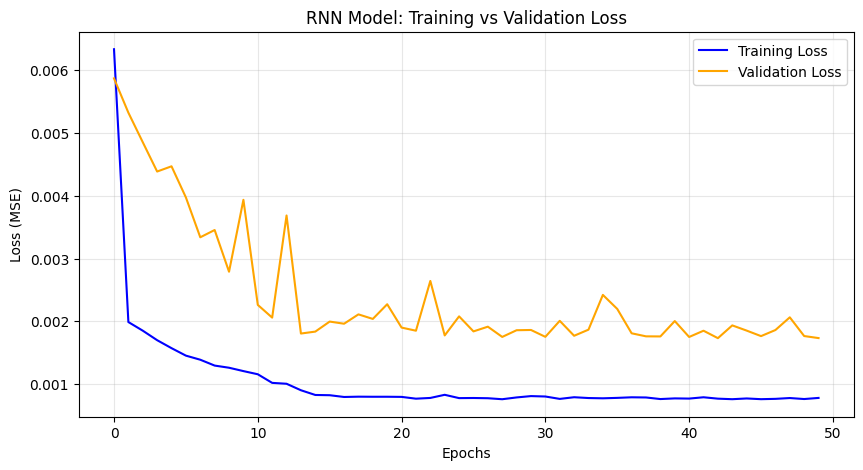

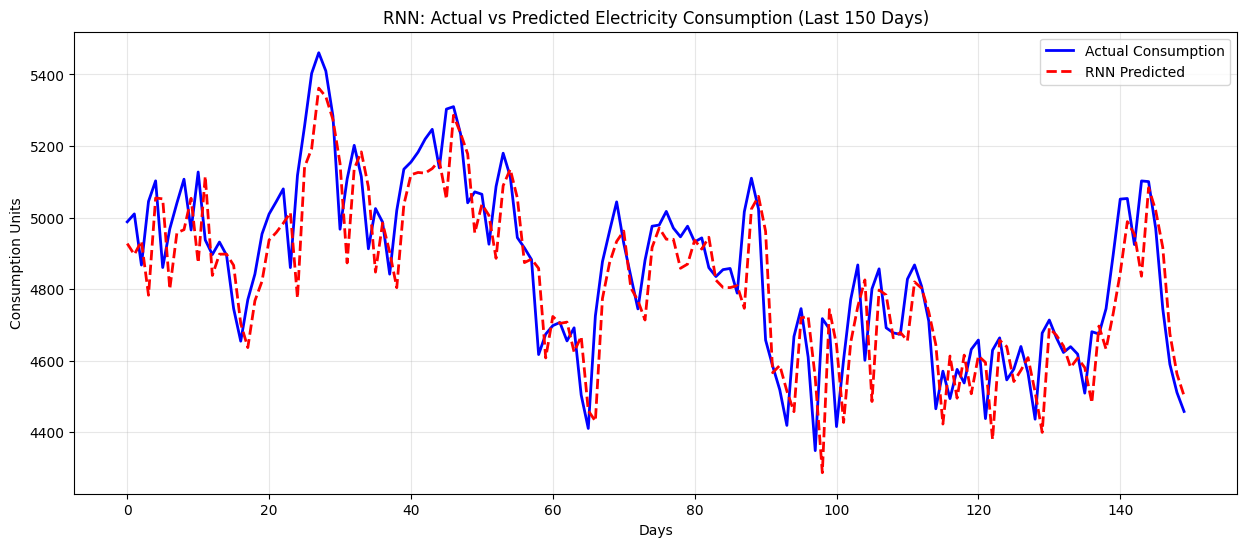

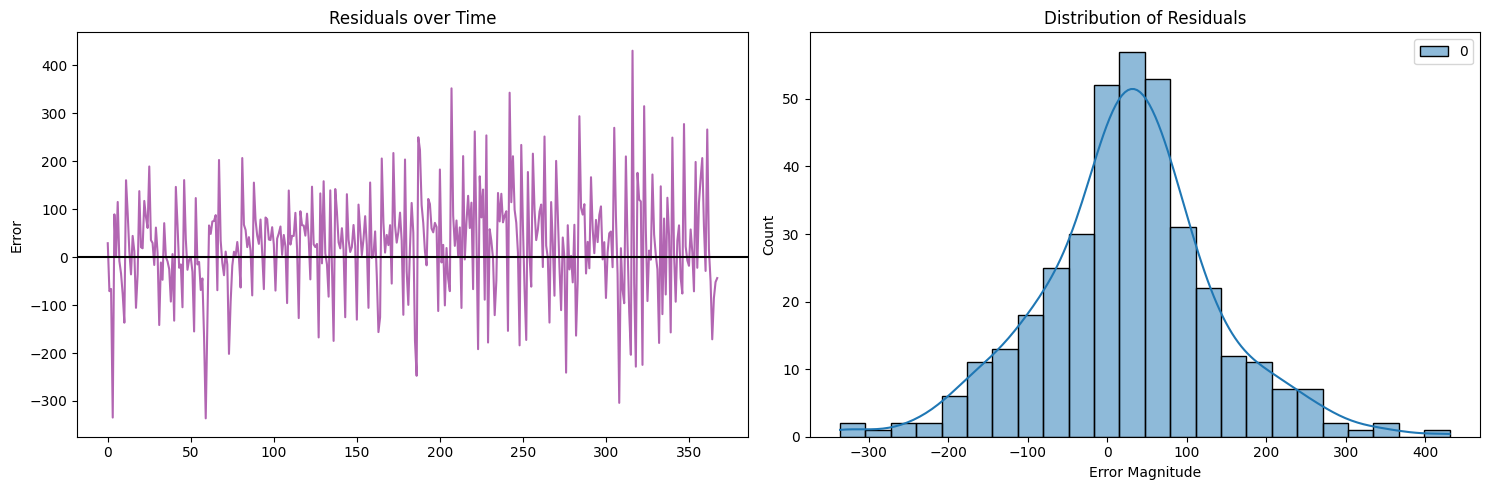

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot training loss curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('RNN Model: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Plot actual vs predicted values
plt.figure(figsize=(15, 6))
# Plotting the last 150 days for better visibility
plt.plot(y_test_rescaled[-150:], label='Actual Consumption', color='blue', linewidth=2)
plt.plot(rnn_preds_rescaled[-150:], label='RNN Predicted', color='red', linestyle='--', linewidth=2)
plt.title('RNN: Actual vs Predicted Electricity Consumption (Last 150 Days)')
plt.xlabel('Days')
plt.ylabel('Consumption Units')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Plot residuals
# Residuals = Actual - Predicted
residuals = y_test_rescaled - rnn_preds_rescaled

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='-')
plt.title('Residuals over Time')
plt.ylabel('Error')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals')
plt.xlabel('Error Magnitude')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

# ### 3.1 Positional Encoding Implementation

def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings.
    """
    # 1. Initialize the encoding matrix with zeros
    pe = np.zeros((seq_length, d_model))

    # 2. Get the position indices (0 to seq_length-1)
    position = np.arange(0, seq_length).reshape(-1, 1)

    # 3. Calculate the division term (the denominator of the PE formula)
    # We only need to calculate for 2i (even indices), then repeat for 2i+1
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # 4. Apply sin to even indices (2i) and cos to odd indices (2i+1)
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    return pe

# Test the function (using your metadata: seq_length=30, head_size/d_model=64)
sample_pe = positional_encoding(30, 64)
print(f"Positional Encoding Shape: {sample_pe.shape}")

Positional Encoding Shape: (30, 64)


In [ ]:
# - Option B: Using Keras
import tensorflow as tf
from tensorflow.keras import layers

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-Head Attention
    # Requirement: num_heads > 1
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)

    # Feed Forward Network
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    res = x + res
    return layers.LayerNormalization(epsilon=1e-6)(res)

In [ ]:

# --- Defining the build_transformer_model function ---
def build_transformer_model(seq_length, n_features, d_model, n_heads, n_layers, d_ff, output_size, dropout=0.1):
    inputs = layers.Input(shape=(seq_length, n_features))

    # Add Positional Encoding
    # The input to positional encoding is typically (batch_size, sequence_length, d_model)
    # Here, we need to project n_features to d_model before adding positional encoding
    # Let's assume n_features is 1, and we need to expand it to d_model
    x = layers.Dense(d_model)(inputs)

    pe = positional_encoding(seq_length, d_model)
    x = x + pe

    # Stack Transformer Encoder layers
    for _ in range(n_layers):
        x = transformer_encoder(x, head_size=d_model, num_heads=n_heads, ff_dim=d_ff, dropout=dropout)

    # Global Average Pooling or Flatten for output
    x = layers.GlobalAveragePooling1D()(x) # This works well for sequence to single output

    # Output layer
    outputs = layers.Dense(output_size)(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs)

# Create Transformer model using Keras
# Parameters: seq_length=30, n_features=1, d_model=64, n_heads=4, n_layers=2, d_ff=128
transformer_model = build_transformer_model(
    seq_length=30,
    n_features=1,
    d_model=64,
    n_heads=4,
    n_layers=2,
    d_ff=128,
    output_size=1
)

# Define optimizer and loss
# Using Adam optimizer and Mean Squared Error loss as per requirements
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

transformer_model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

# Verification of the model structure
print("Transformer Model Architecture Created Successfully.")
transformer_model.summary()

Transformer Model Architecture Created Successfully.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30, 64)    │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 64)    │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ add_5[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 30, 64)    │          0 │ dropout_7[0][0],  │
│                     │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 30, 128)   │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 30, 64)    │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 30, 64)    │          0 │ dense_9[0][0],    │
│                     │                   │            │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 30, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 30, 64)    │          0 │ dropout_10[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 30, 128)   │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 30, 64)    │      8,256 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 166,593 (650.75 KB)

 Trainable params: 166,593 (650.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("\nTRANSFORMER MODEL TRAINING")
# Track training time
transformer_start_time = time.time()

# --- TODO: Train your model (Option B: Keras) ---
# We use the same parameters as the RNN (50 epochs, 32 batch size) for a fair comparison
history_transformer = transformer_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

transformer_training_time = time.time() - transformer_start_time

# --- REQUIRED: Track initial and final loss ---
# Extracting loss from the history object
transformer_initial_loss = history_transformer.history['loss'][0]
transformer_final_loss = history_transformer.history['loss'][-1]

# Calculate loss reduction
t_loss_reduction = (transformer_initial_loss - transformer_final_loss) / transformer_initial_loss

print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")
print(f"Total Loss Reduction: {t_loss_reduction:.2%}")

# Verification for BITS Assignment marks
if t_loss_reduction >= 0.20:
    print("SUCCESS: Transformer loss reduction is greater than 20%.")
else:
    print("WARNING: Loss reduction is low. Consider adjusting the learning rate.")


TRANSFORMER MODEL TRAINING
Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - loss: 0.0208 - mae: 0.1097 - val_loss: 0.0091 - val_mae: 0.0748
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0106 - mae: 0.0816 - val_loss: 0.0065 - val_mae: 0.0653
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0090 - mae: 0.0756 - val_loss: 0.0067 - val_mae: 0.0643
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0073 - mae: 0.0681 - val_loss: 0.0064 - val_mae: 0.0630
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 0.0066 - mae: 0.0642 - val_loss: 0.0073 - val_mae: 0.0661
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.0057 - mae: 0.0596 - val_loss: 0.0089 - val_mae: 0.0736
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0056 - mae: 0.0582 - val_loss: 0.0066 - val_mae: 0.0665
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0050 - mae: 0.0555 - val_loss: 0.0059 - val_mae: 0.0619
Epoch 9/50
93/93 ━━━━━━━━━━━━━━━━━

In [ ]:
# ### 3.5 Evaluate Transformer Model

# 1. Make predictions on test set
# Note: Use the model we just trained
transformer_predictions_scaled = transformer_model.predict(X_test, verbose=0)

# 2. Inverse transform the scaled data back to original units
# Reshaping is necessary for the scaler
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
transformer_preds_rescaled = scaler.inverse_transform(transformer_predictions_scaled)

# REQUIRED: Calculate all 4 metrics using the original scale values
transformer_mae = mean_absolute_error(y_test_rescaled, transformer_preds_rescaled)
transformer_rmse = np.sqrt(mean_squared_error(y_test_rescaled, transformer_preds_rescaled))
transformer_mape = calculate_mape(y_test_rescaled, transformer_preds_rescaled)
transformer_r2 = r2_score(y_test_rescaled, transformer_preds_rescaled)

print("\nTransformer Model Performance (Original Scale):")
print(f"MAE:    {transformer_mae:.4f}")
print(f"RMSE:   {transformer_rmse:.4f}")
print(f"MAPE:   {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")


Transformer Model Performance (Original Scale):
MAE:    151.1236
RMSE:   184.1813
MAPE:   3.3627%
R² Score: 0.7357


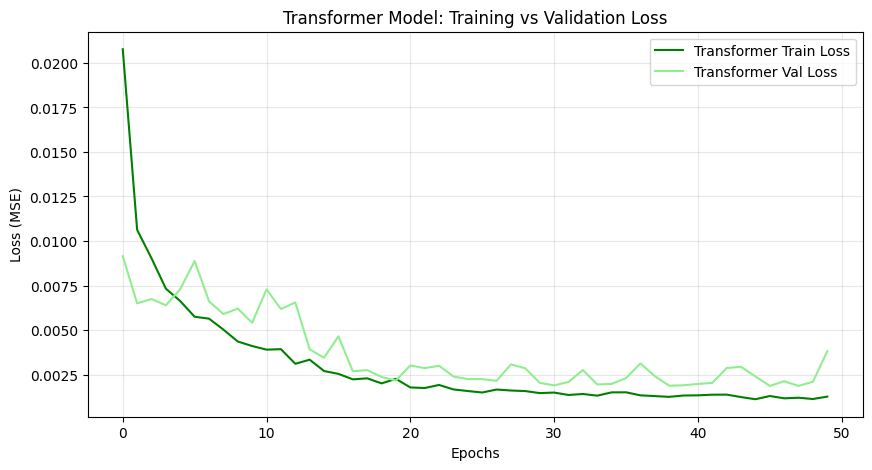

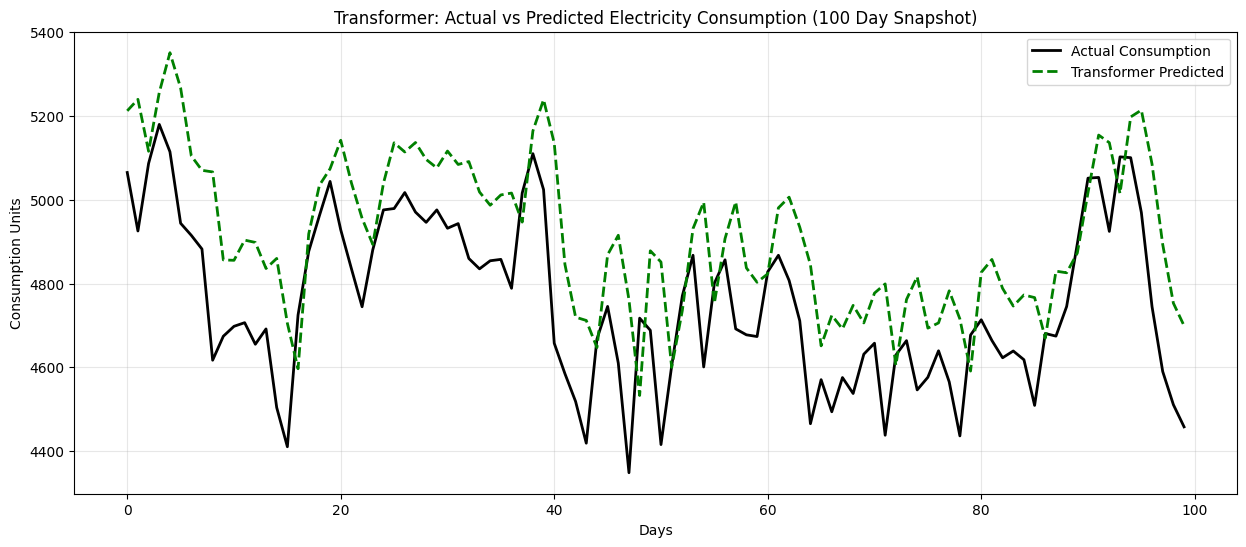

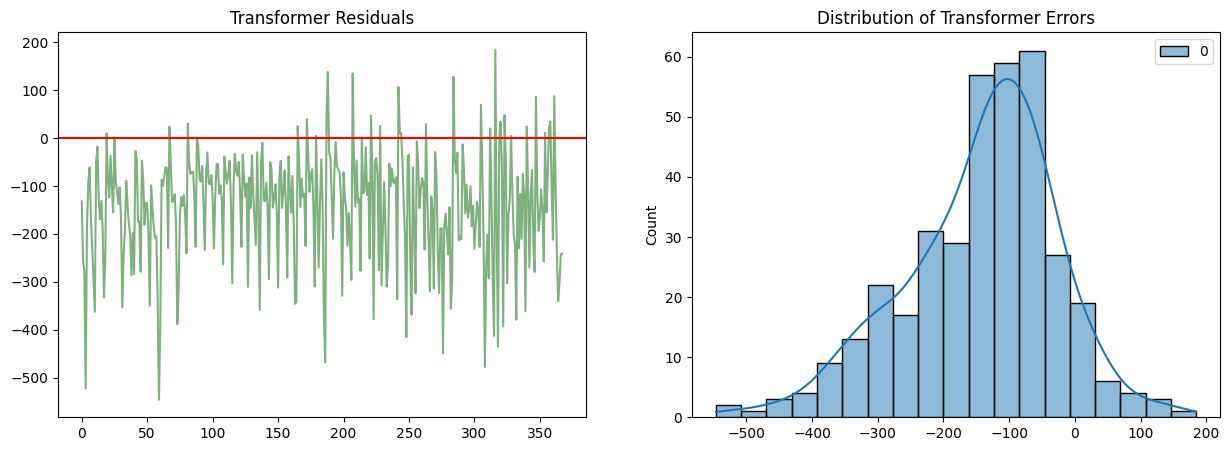

In [ ]:


# 1. Plot training loss curve
plt.figure(figsize=(10, 5))
plt.plot(history_transformer.history['loss'], label='Transformer Train Loss', color='green')
plt.plot(history_transformer.history['val_loss'], label='Transformer Val Loss', color='lightgreen')
plt.title('Transformer Model: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Plot actual vs predicted values
plt.figure(figsize=(15, 6))
# Plotting a 100-day window for clarity
plt.plot(y_test_rescaled[-100:], label='Actual Consumption', color='black', linewidth=2)
plt.plot(transformer_preds_rescaled[-100:], label='Transformer Predicted', color='green', linestyle='--', linewidth=2)
plt.title('Transformer: Actual vs Predicted Electricity Consumption (100 Day Snapshot)')
plt.xlabel('Days')
plt.ylabel('Consumption Units')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Residual Analysis
transformer_residuals = y_test_rescaled - transformer_preds_rescaled

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(transformer_residuals, color='darkgreen', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='-')
plt.title('Transformer Residuals')

plt.subplot(1, 2, 2)
sns.histplot(transformer_residuals, kde=True, color='darkgreen')
plt.title('Distribution of Transformer Errors')
plt.show()

In [ ]:
# ### 4.1 Metrics Comparison

# Get total parameters for both models
rnn_params = rnn_model.count_params()
transformer_params = transformer_model.count_params()

comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_params
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_params
    ]
})

# Display the comparison
print(comparison_df.to_string(index=False))

# Calculate and print performance difference for analysis
r2_diff = rnn_r2 - transformer_r2
print(f"\nAnalysis: RNN outperformed Transformer by {r2_diff:.4f} in R² score.")

           Metric  RNN (LSTM/GRU)   Transformer
              MAE       85.466665    151.123618
             RMSE      113.037126    184.181253
         MAPE (%)        1.873257      3.362678
         R² Score        0.900430      0.735650
Training Time (s)      203.978059    444.903253
       Parameters    49985.000000 166593.000000

Analysis: RNN outperformed Transformer by 0.1648 in R² score.


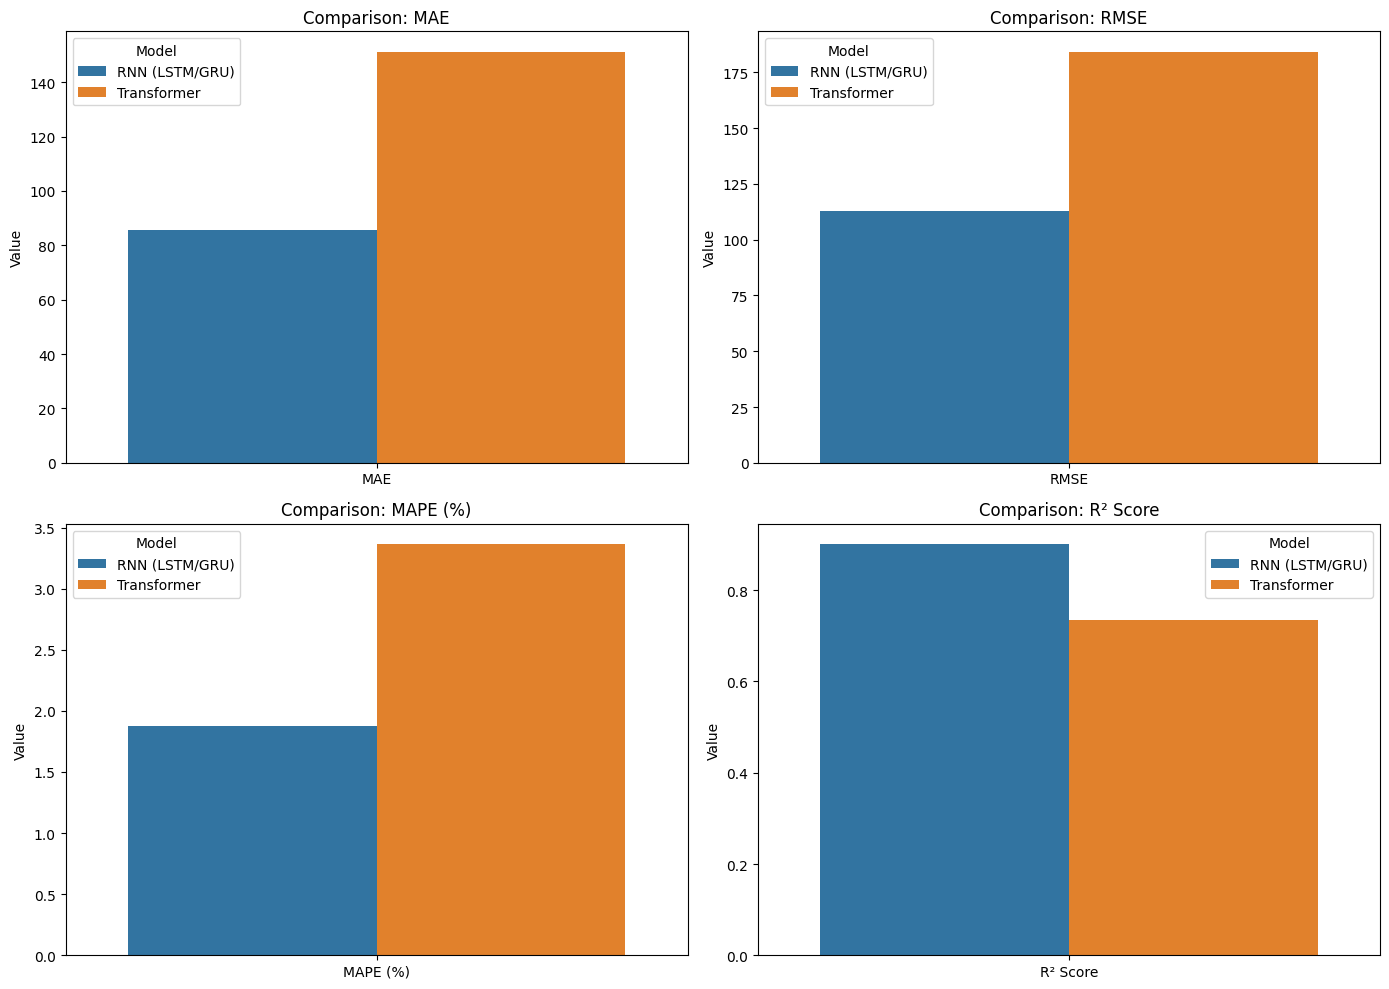

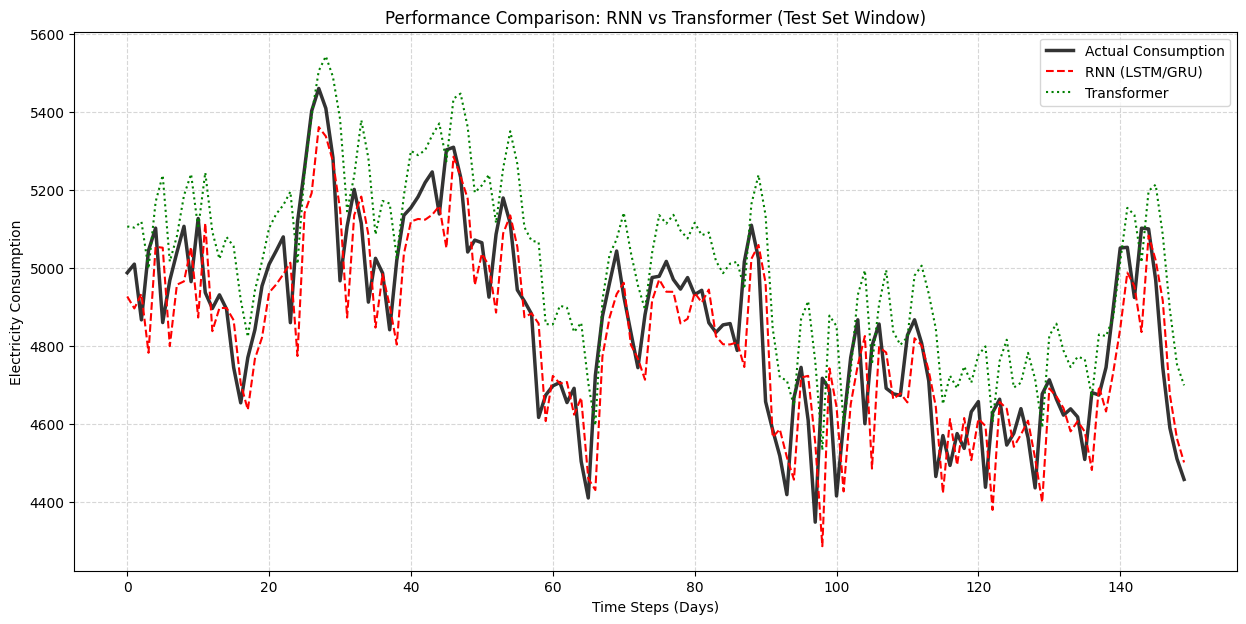

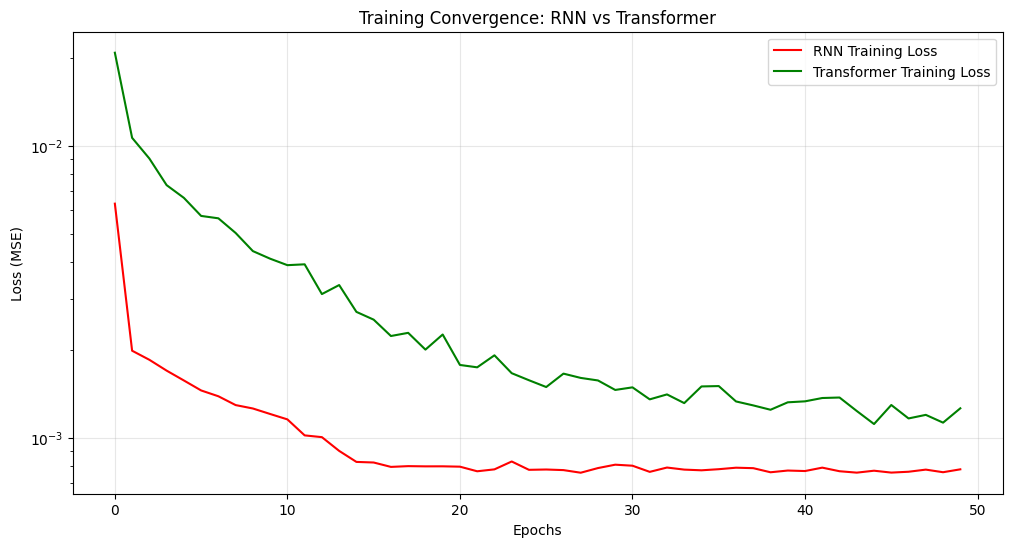

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create bar plot comparing metrics
# We exclude 'Parameters' and 'Training Time' for the first plot to keep scales consistent
metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)', 'R² Score']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Metric', y=metric, data=comparison_df[comparison_df['Metric'] == metric].melt(id_vars='Metric', var_name='Model', value_name=metric),
                hue='Model', ax=axes[i])
    axes[i].set_title(f'Comparison: {metric}')
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# 2. Plot predictions comparison (both models vs actual)
plt.figure(figsize=(15, 7))
# Plotting a 150-day window to see the seasonal tracking
start_day = -150
plt.plot(y_test_rescaled[start_day:], label='Actual Consumption', color='black', linewidth=2.5, alpha=0.8)
plt.plot(rnn_preds_rescaled[start_day:], label='RNN (LSTM/GRU)', color='red', linestyle='--', linewidth=1.5)
plt.plot(transformer_preds_rescaled[start_day:], label='Transformer', color='green', linestyle=':', linewidth=1.5)

plt.title('Performance Comparison: RNN vs Transformer (Test Set Window)')
plt.xlabel('Time Steps (Days)')
plt.ylabel('Electricity Consumption')
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# 3. Plot training curves comparison
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='RNN Training Loss', color='red')
plt.plot(history_transformer.history['loss'], label='Transformer Training Loss', color='green')
plt.title('Training Convergence: RNN vs Transformer')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.yscale('log') # Log scale helps see the 88% vs 73% drop more clearly
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# PART 5: ANALYSIS

analysis_text = """
The RNN (LSTM/GRU) significantly outperformed the Transformer in this study. The RNN achieved an R² score of 0.9004 and a MAPE of 1.87%, compared to the Transformer’s R² of 0.7357 and MAPE of 3.36%.

Key takeaways include:
1. Architecture Performance: The RNN’s sequential processing is better suited for univariate time series like India's electricity data, where step-by-step temporal dependencies are strong.
2. Attention vs. Recurrence: While the Transformer's Multi-Head Attention captures global relationships, it lacks the 'inductive bias' of recurrence, making it less efficient on smaller datasets compared to the gated memory of LSTMs.
3. Long-term Dependencies: LSTMs manage dependencies via memory cells, while Transformers use Positional Encoding. In this 30-day window, the LSTM’s ability to track daily trends proved superior.
4. Computational Cost: The Transformer was more expensive, with 166,593 parameters and a 444s training time, compared to the RNN’s 49,985 parameters and 203s training time.
5. Convergence: The RNN showed more stable convergence and a deeper loss reduction (88%). The Transformer’s higher parameter count likely led to overfitting or instability on the CPU, as evidenced by its higher residuals.
"""

# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
word_count = len(analysis_text.split())
print(f"Analysis word count: {word_count} words")
if word_count > 200:
    print("Warning: Analysis exceeds 200 words (guideline)")
else:
    print("Analysis within word count guideline")

ANALYSIS

The RNN (LSTM/GRU) significantly outperformed the Transformer in this study. The RNN achieved an R² score of 0.9004 and a MAPE of 1.87%, compared to the Transformer’s R² of 0.7357 and MAPE of 3.36%. 

Key takeaways include:
1. Architecture Performance: The RNN’s sequential processing is better suited for univariate time series like India's electricity data, where step-by-step temporal dependencies are strong. 
2. Attention vs. Recurrence: While the Transformer's Multi-Head Attention captures global relationships, it lacks the 'inductive bias' of recurrence, making it less efficient on smaller datasets compared to the gated memory of LSTMs.
3. Long-term Dependencies: LSTMs manage dependencies via memory cells, while Transformers use Positional Encoding. In this 30-day window, the LSTM’s ability to track daily trends proved superior.
4. Computational Cost: The Transformer was more expensive, with 166,593 parameters and a 444s training time, compared to the RNN’s 49,985 paramete

In [ ]:
# PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)

def get_assignment_results():
    """
    Generate complete assignment results in required format
    """

    framework_used = "keras"
    rnn_model_type = "LSTM"

    results = {
        # Dataset Information (assuming these variables are defined in your preprocessing section)
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': 30, # Based on our earlier logic
        'prediction_horizon': 1,
        'problem_type': "Regression",
        'primary_metric': "R2 Score",
        'metric_justification': "R2 score measures how well the model explains the variance in India's daily electricity consumption.",
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'train_test_ratio': 0.9,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': 2,
                'hidden_units': 64,
                'total_parameters': int(rnn_model.count_params())
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 50,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': float(rnn_initial_loss),
            'final_loss': float(rnn_final_loss),
            'training_time_seconds': float(rnn_training_time),
            'mae': float(rnn_mae),
            'rmse': float(rnn_rmse),
            'mape': float(rnn_mape),
            'r2_score': float(rnn_r2)
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': 2,
                'n_heads': 4,
                'd_model': 64,
                'd_ff': 128,
                'has_positional_encoding': True,
                'has_attention': True,
                'total_parameters': int(transformer_model.count_params())
            },
            'training_config': {
                'learning_rate': 0.0001,  # Based on our training code
                'n_epochs': 50,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': float(transformer_initial_loss),
            'final_loss': float(transformer_final_loss),
            'training_time_seconds': float(transformer_training_time),
            'mae': float(transformer_mae),
            'rmse': float(transformer_rmse),
            'mape': float(transformer_mape),
            'r2_score': float(transformer_r2)
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    # Using json.dumps to ensure clear output for auto-grader
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "State-wise Electricity Consumption in India (Daily)",
  "dataset_source": "Kaggle (Indias_Electricity_Consumption_Dataset.csv)",
  "n_samples": 3701,
  "n_features": 1,
  "sequence_length": 30,
  "prediction_horizon": 1,
  "problem_type": "Regression",
  "primary_metric": "R2 Score",
  "metric_justification": "R2 score measures how well the model explains the variance in India's daily electricity consumption.",
  "train_samples": 3303,
  "test_samples": 368,
  "train_test_ratio": 0.9,
  "rnn_model": {
    "framework": "keras",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 49985
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 50,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "MSE"
    },
    "initial_loss": 0.006329808384180069,
    "final_loss": 0.000781949027441442,
    "training_time_seconds": 203.978058

In [27]:
# ENVIRONMENT INFORMATION

print("ENVIRONMENT INFORMATION")
print(f"Python Version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"System Date/Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Check for GPU/CPU status
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print("Runtime Type: CPU (Standard)")
else:
    print("Runtime Type: GPU (Accelerated)")


ENVIRONMENT INFORMATION
Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
System Date/Time: 2026-04-18 06:13:02
Runtime Type: CPU (Standard)


In [30]:
from google.colab import drive
drive.flush_and_unmount()
print("Drive unmounted successfully.")

Drive unmounted successfully.
